# Notebook 2 — Otimização de Hiperparâmetros com CMA-ES

Estratégia de Evolução com Adaptação de Matriz de Covariância.
O CMA-ES mantém uma distribuição Gaussiana multivariada sobre o espaço de busca
e adapta sua média e covariância com base nos melhores candidatos de cada geração.

Espaço de busca: Todos os parâmetros são normalizados para [0, 1].
O CMA-ES usa bounds=[0, 1] nativo para tratamento de restrições por transformação,
evitando a codificação ad-hoc não-linear do código original.

Correções em relação ao código original:
- Codificação redesenhada em [0, 1] uniformizado
- Budget de avaliações respeitado exatamente (controle por n_evals)
- Rastreamento de best_params (ausente no original)

In [1]:
import sys, os
sys.path.insert(0, "..")
os.makedirs("results", exist_ok=True)
os.makedirs("sim_cache", exist_ok=True)

import numpy as np
import torch
import json
import cma

from common import (
    get_device, device_info, load_or_simulate, extract_dataset,
    make_objective, compute_metrics, encode_params,
    SIGMA_LEVELS, N_TRIALS, N_SEEDS, N_OSCILLATORS, LAM,
    T_SPAN, DT, N_TRAJS, SAVE_EVERY, N_EPOCHS_OBJ, PATIENCE_OBJ,
    SIM_CACHE_DIR, RESULTS_DIR, ACTIVATIONS, BATCH_SIZES, PARAM_NAMES,
)

DEVICE = get_device()
print(f"Device: {device_info(DEVICE)}")

Device: CUDA — NVIDIA GeForce RTX 4090 (25.3 GB)


In [2]:
def decode_cma(x: np.ndarray) -> dict:
    """
    Decodifica vetor em [0, 1]^6 para hiperparâmetros reais.

    Espaço normalizado:
        x[0] → lr          (log-uniform em [1e-4, 1e-2])
        x[1] → hidden_dim  (inteiro em [32, 256])
        x[2] → n_layers    (inteiro em [1, 4])
        x[3] → activation  (índice em {0, 1, 2, 3})
        x[4] → batch_size  (índice em {0, 1, 2, 3})
        x[5] → weight_decay (log-uniform em [1e-6, 1e-2])
    """
    x = np.clip(x, 0.0, 1.0)
    lr  = float(np.exp(np.log(1e-4) + x[0] * (np.log(1e-2) - np.log(1e-4))))
    hd  = int(round(32.0 + x[1] * (256.0 - 32.0)))
    nl  = int(round(1.0  + x[2] * 3.0))
    ai  = int(round(x[3] * 3.0))
    bi  = int(round(x[4] * 3.0))
    wd  = float(np.exp(np.log(1e-6) + x[5] * (np.log(1e-2) - np.log(1e-6))))
    return {
        "lr":           float(np.clip(lr, 1e-4, 1e-2)),
        "hidden_dim":   int(np.clip(hd, 32, 256)),
        "n_layers":     int(np.clip(nl, 1, 4)),
        "activation":   ACTIVATIONS[int(np.clip(ai, 0, 3))],
        "batch_size":   BATCH_SIZES[int(np.clip(bi, 0, 3))],
        "weight_decay": float(np.clip(wd, 1e-6, 1e-2)),
    }


def run_cmaes(objective_fn, n_trials: int, seed: int) -> dict:
    """
    Executa CMA-ES e retorna histórico e melhores resultados.

    Melhorias vs. código original:
    1. Espaço [0, 1] com bounds nativo do CMA (transformação interna)
    2. Budget `n_trials` respeitado via contador `n_evals` independente
       do tamanho da população (o original podia exceder n_trials)
    3. Rastreamento de best_params
    """
    x0     = [0.5] * 6            # ponto inicial: centro do espaço
    sigma0 = 0.3                   # sigma inicial: 30% do range [0,1]

    es = cma.CMAEvolutionStrategy(x0, sigma0, {
        "seed":     seed,
        "bounds":   [0.0, 1.0],   # CMA aplica transformação interna
        "verbose":  -9,
    })

    history: list[float] = []
    all_params: list[dict] = []
    best_val  = float("inf")
    best_par  = None

    while not es.stop() and len(history) < n_trials:
        remaining  = n_trials - len(history)
        solutions  = es.ask()                         # população (lista de arrays)
        solutions  = solutions[:remaining]            # truncar se necessário
        fitnesses  = [objective_fn(decode_cma(x)) for x in solutions]
        es.tell(solutions, fitnesses)

        for x, f in zip(solutions, fitnesses):
            history.append(float(f))
            params = decode_cma(x)
            all_params.append(params)
            if f < best_val:
                best_val = f
                best_par = params

    return {
        "best_value":         best_val,
        "best_params":        best_par,
        "history":            history,
        "all_params_encoded": [encode_params(p) for p in all_params],
        "metrics":            compute_metrics(history),
    }

In [3]:
results = {}

for sigma_J in SIGMA_LEVELS:
    results[str(sigma_J)] = {}
    print(f"\n{'='*50}")
    print(f"sigma_J = {sigma_J}")
    print(f"{'='*50}")

    for seed in range(N_SEEDS):
        print(f"  Seed {seed}/{N_SEEDS-1}", end=" | ", flush=True)

        J_np, states = load_or_simulate(
            SIM_CACHE_DIR, N_OSCILLATORS, sigma_J, LAM,
            N_TRAJS, T_SPAN, DT, DEVICE, seed, SAVE_EVERY,
        )
        X, Y = extract_dataset(states, J_np, LAM)
        print(f"Dataset: {len(X):,} amostras", end=" | ", flush=True)

        objective_fn = make_objective(X, Y, N_OSCILLATORS, DEVICE,
                                      n_epochs=N_EPOCHS_OBJ,
                                      patience=PATIENCE_OBJ)
        res = run_cmaes(objective_fn, N_TRIALS, seed)
        results[str(sigma_J)][str(seed)] = res

        best = res["best_value"]
        t10  = res["metrics"]["t10"]
        print(f"Best val_loss={best:.4e}, t10={t10}", flush=True)

os.makedirs(RESULTS_DIR, exist_ok=True)
out_path = os.path.join(RESULTS_DIR, "cmaes_results.json")
with open(out_path, "w") as f:
    json.dump({"method": "cmaes", "results": results}, f, indent=2)

print(f"\nResultados salvos em: {out_path}")


sigma_J = 0.0
  Seed 0/2 | 

Dataset: 40,000 amostras | 

Best val_loss=2.9602e-05, t10=47


  Seed 1/2 | 

Dataset: 40,000 amostras | 

...

Best val_loss=4.8640e-04, t10=48


  Seed 2/2 | 

Dataset: 40,000 amostras | 

Best val_loss=1.1370e-03, t10=38



Resultados salvos em: results/cmaes_results.json


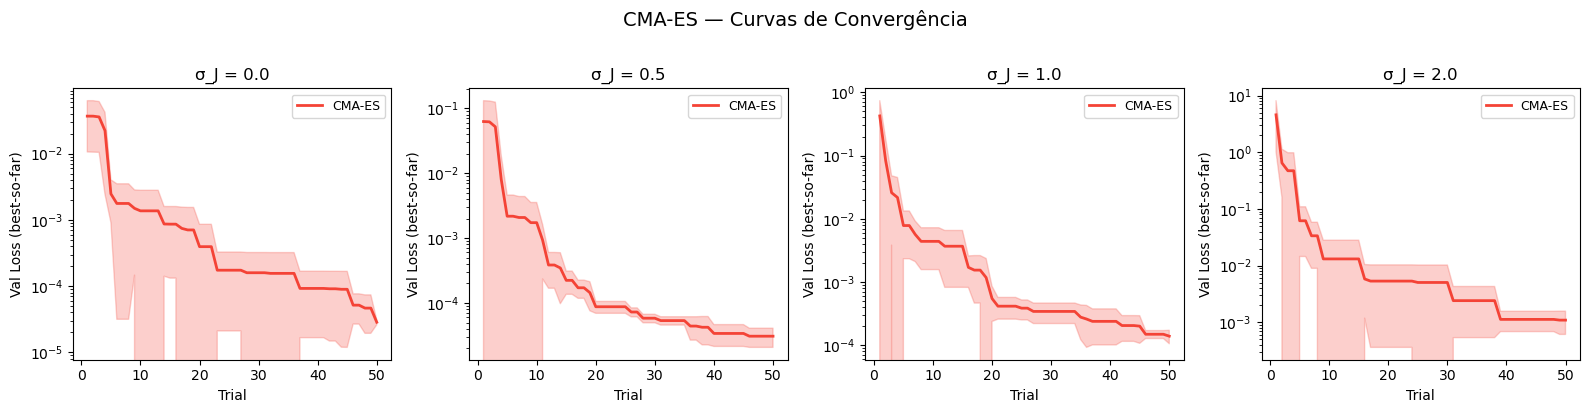

Plot salvo.


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(SIGMA_LEVELS), figsize=(16, 4), sharey=False)
color = "#F44336"

for ax, sigma_J in zip(axes, SIGMA_LEVELS):
    histories = [
        np.minimum.accumulate(results[str(sigma_J)][str(s)]["history"])
        for s in range(N_SEEDS)
    ]
    max_len = max(len(h) for h in histories)
    padded = [np.pad(h, (0, max_len - len(h)), mode="edge") for h in histories]
    mean = np.mean(padded, axis=0)
    std  = np.std(padded, axis=0)
    trials = np.arange(1, len(mean) + 1)

    ax.plot(trials, mean, color=color, lw=2, label="CMA-ES")
    ax.fill_between(trials, mean - std, mean + std, alpha=0.25, color=color)
    ax.set_title(f"σ_J = {sigma_J}", fontsize=12)
    ax.set_xlabel("Trial")
    ax.set_ylabel("Val Loss (best-so-far)")
    ax.set_yscale("log")
    ax.legend(fontsize=9)

plt.suptitle("CMA-ES — Curvas de Convergência", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cmaes_convergence.pdf"), bbox_inches="tight", dpi=150)
plt.show()
print("Plot salvo.")